In [ ]:
from spicexplorer.optimization.orchestrator import Circuit_Optimizer_Orchestrator_with_SPICE, Optimizer_Type_Enum
from spicexplorer.logging.logger_setup import setup_loggers_with_spicelib_suppression as setup_loggers

from pathlib        import Path
from datetime       import datetime


logger = setup_loggers()

TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")


BASE_SAVE_DIR = Path(f"./save/save_opt_{TIMESTAMP}")
# BASE_SAVE_DIR = Path(f"./save")
BASE_SAVE_DIR.mkdir(exist_ok=True, parents=True)
logger.critical(f"Optimization Notebook - results will be saved to {BASE_SAVE_DIR.absolute()}")

## Comparison to Manual Design of Cascode (Telescopic) OTA
From JKU IIC github page. Available [here](https://github.com/iic-jku/analog-circuit-design).

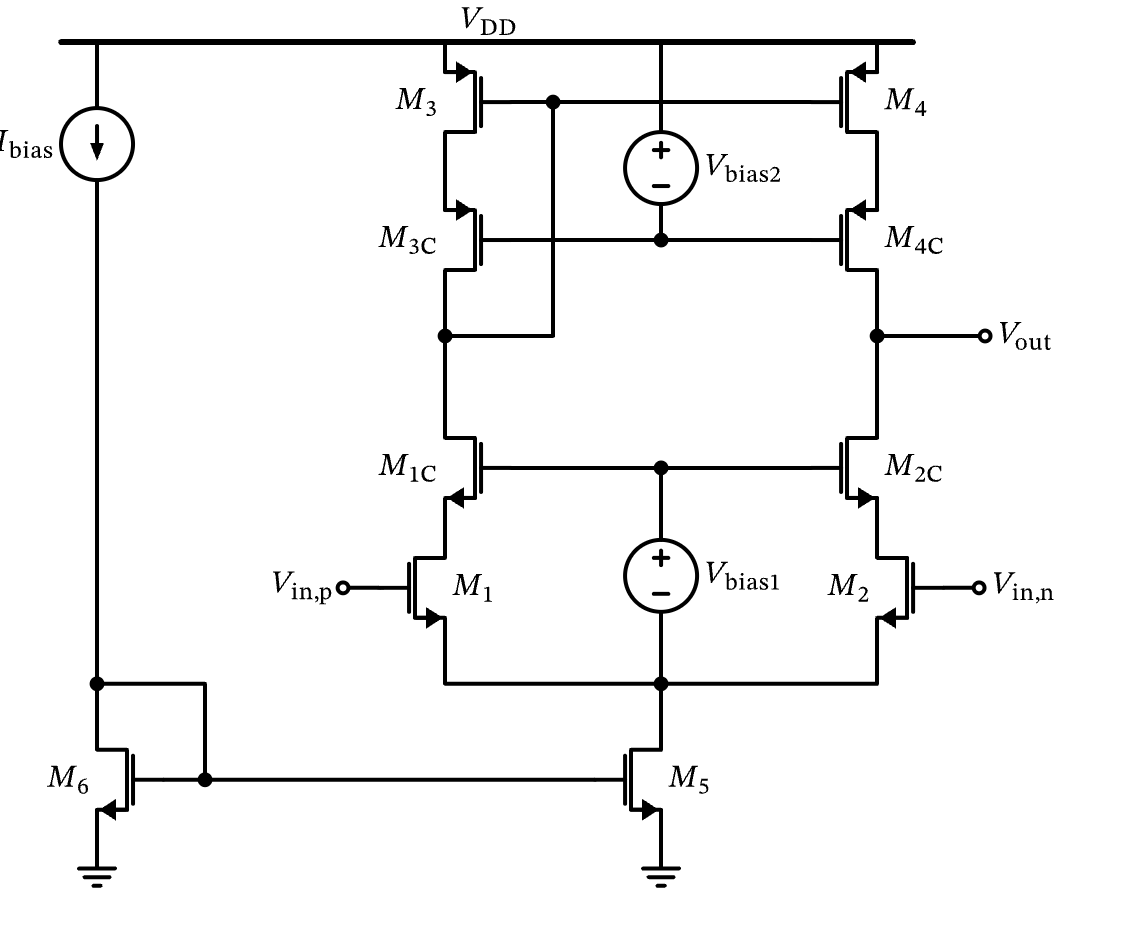
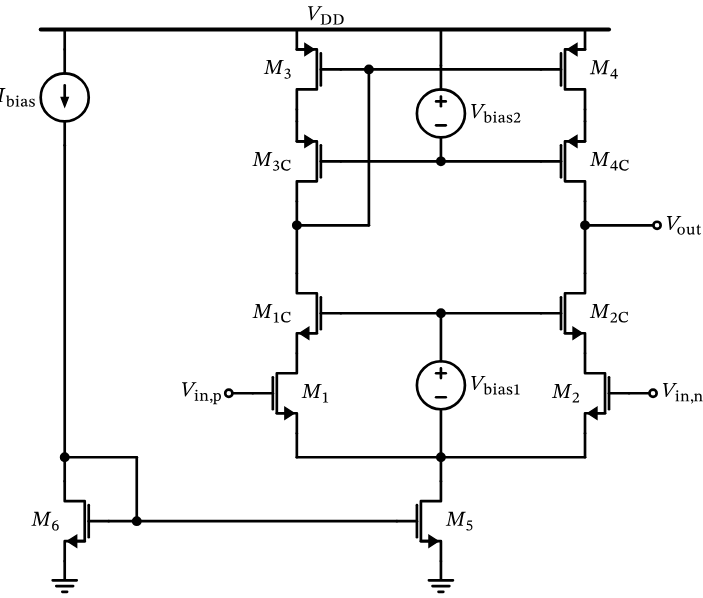

# Setup the Optimizer

In [ ]:
path_to_project_setup = Path("./project_setup.yaml")
optimizer_type = Optimizer_Type_Enum.NEVERGRAD_SINGLE

In [ ]:
orchestrator = Circuit_Optimizer_Orchestrator_with_SPICE(
    project_setup_path=path_to_project_setup,
    optimizer_type=optimizer_type,
    auto_load=False,
    verbose=True
)

# Update the temp path
temp_dir = f"{orchestrator.project_setup.outdir}_{TIMESTAMP}"
orchestrator.project_setup.outdir = f"{orchestrator.project_setup.outdir}_{TIMESTAMP}"
logger.info(f"overwrote project_setup.outdir with {temp_dir}")

orchestrator.initialize()


optimizer = orchestrator.get_optimizer()
optimizer.parameterize()
# orchestrator.run_sanity_on_spicelib_wrapper()

# Run the Optimization Loop

In [ ]:
optimizer.optimize(render_optimization_trace=True, keep_history=False)

## Viewing the Optimization Results

In [ ]:
optimizer.setup_obj.optimizer_config.target_specs.list_target_names()

In [ ]:
optimizer.plot_optimization_trace(metric_x="ugf", metric_y="dcgain", show=True, save_path=BASE_SAVE_DIR/Path("./ugf_dcgain.html"))

optimizer.plot_optimization_trace(metric_y="ugf", metric_x="i(idd_total)", show=True, save_path=BASE_SAVE_DIR/Path("./ugf_idd_total.html"))
optimizer.plot_optimization_trace(metric_y="dcgain", metric_x="i(idd_total)", show=True, save_path=BASE_SAVE_DIR/Path("./dcgain_idd_total.html"))

optimizer.plot_optimization_trace(metric_x="ugf", metric_y="v(inoise_total)", show=True, save_path=BASE_SAVE_DIR/Path("./ugf_inoise.html"))
optimizer.plot_optimization_trace(metric_x="dcgain", metric_y="v(inoise_total)", show=True,  save_path=BASE_SAVE_DIR/Path("./dcgain_inoise.html"))

optimizer.plot_optimization_trace(metric_x="ugf", metric_y="pm", show=True,  save_path=BASE_SAVE_DIR/Path("./ugf_pm.html"))
optimizer.plot_optimization_trace(metric_x="ugf", metric_y="tsettle", show=True,  save_path=BASE_SAVE_DIR/Path("./ugf_tsettle.html"))
optimizer.plot_optimization_trace(metric_x="dcgain", metric_y="tsettle", show=True,  save_path=BASE_SAVE_DIR/Path("./dcgain_tsettle.html"))
optimizer.plot_optimization_trace(metric_x="pm", metric_y="tsettle", show=True,  save_path=BASE_SAVE_DIR/Path("./pm_tsettle.html"))

In [ ]:
optimizer.spicelib_wrappers['tb_ac'].get_dut_params()

In [ ]:
optimizer.plot_design_space_exploration(param_x="X_DUT_M1CM2C_L", param_y="X_DUT_M1CM2C_W", show=True)

In [ ]:
optimizer.get_best_params(verbose=True)

# Saving the Results

In [ ]:
logger.critical(f"Notebook - Saving the results...")
save_path = BASE_SAVE_DIR/Path(f"{orchestrator.project_setup.optimizer_config.name}_{orchestrator.project_setup.optimizer_config.budget}_score.html")
optimizer.plot_score(show=False, save_path=save_path)

In [ ]:
save_path = BASE_SAVE_DIR/Path(f"{orchestrator.project_setup.optimizer_config.name}_{orchestrator.project_setup.optimizer_config.budget}")
optimizer.save_checkpoint(name=save_path)

## Cleanup

In [ ]:
# Uncomment the following line to clean up temporary files created during optimization
# optimizer.clean_up()